In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("netflix_titles.xlsx")
print(df.shape)      # rows, columns
print(df.info())     # data types

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [6]:
df.dropna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24 00:00:00,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09 00:00:00,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20 00:00:00,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01 00:00:00,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11 00:00:00,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [7]:
clean_df = df.dropna()

In [8]:
clean_df.duplicated()

1       False
2       False
4       False
5       False
6       False
        ...  
8801    False
8802    False
8804    False
8805    False
8806    False
Length: 7965, dtype: bool

In [9]:
clean_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24 00:00:00,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09 00:00:00,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20 00:00:00,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01 00:00:00,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11 00:00:00,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [10]:
clean_df.duplicated().sum()

0

In [11]:
clean_df["type"].value_counts()

type
Movie      5651
TV Show    2314
Name: count, dtype: int64

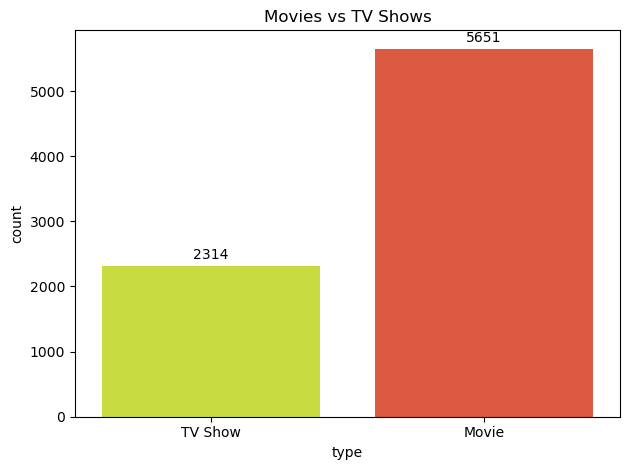

In [12]:
##MOVIES AND TV SHOWS NUMBERS 
ax = sns.countplot(
    x="type",
    hue="type",
    data=clean_df,
    palette={
        "Movie": "#F54927",
        "TV Show": "#DAF527"
    },
legend=False
)
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Movies vs TV Shows")
plt.tight_layout()
plt.show()

In [13]:
year = clean_df["release_year"].value_counts()

year = year.sort_index()
print(year)

release_year
1942       1
1944       1
1945       1
1946       1
1947       1
        ... 
2017     910
2018    1025
2019     917
2020     827
2021     494
Name: count, Length: 72, dtype: int64


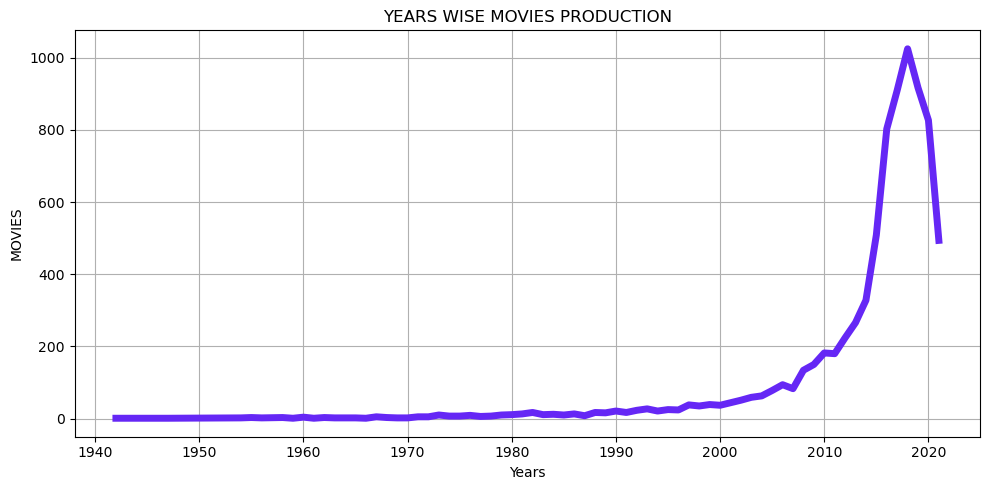

In [14]:
##YEAR WISE MOVIES AND TV SHOW PRODUCTION GRAPH
year = clean_df["release_year"].value_counts().sort_index()
plt.figure(figsize=(10,5))

plt.plot(
    year.index,
    year.values,
    linewidth = 5,
    color = "#6527F5"
)
plt.xlabel("Years")
plt.ylabel("MOVIES")
plt.title("YEARS WISE MOVIES PRODUCTION")
plt.grid(True)
plt.tight_layout()
plt.show()

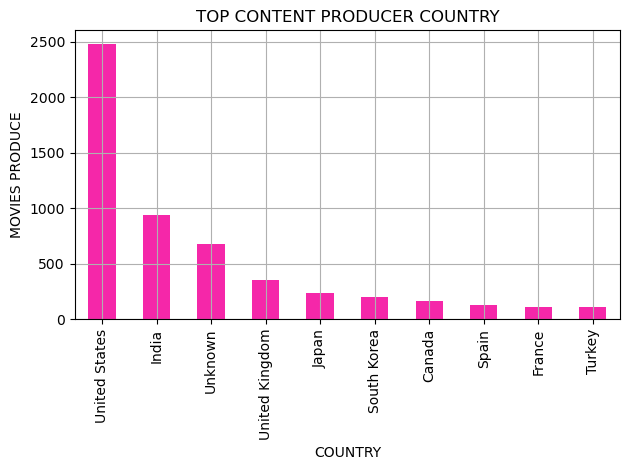

In [15]:
country = (clean_df["country"].value_counts().head(10))
country.plot(kind="bar",color="#F527A9")
plt.xlabel("COUNTRY")
plt.ylabel("MOVIES PRODUCE")
plt.title("TOP CONTENT PRODUCER COUNTRY")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\sahus\AppData\Local\Temp\ipykernel_2816\3025394437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


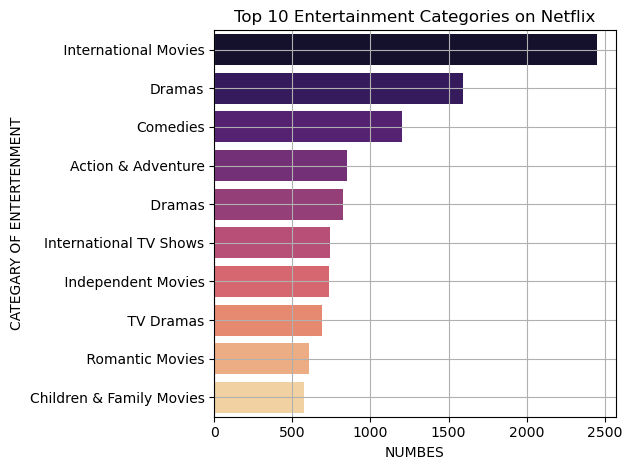

In [16]:
genre = (clean_df["listed_in"].str.split(",").explode())
genre.value_counts().head(10)
sns.barplot(
x=genre.value_counts().head(10).values,
y=genre.value_counts().head(10).index,
palette="magma")
plt.xlabel("NUMBES")
plt.ylabel("CATEGARY OF ENTERTENMENT")
plt.title("Top 10 Entertainment Categories on Netflix")
plt.grid(True)
plt.tight_layout()
plt.show()

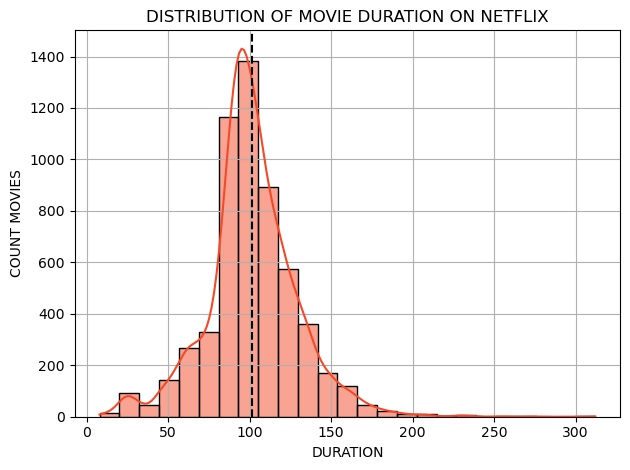

In [17]:
##BAR CHART ACCORDING TO MOVIES DURATION
movie = clean_df[clean_df["type"]=="Movie"].copy()

movie["duration"] = (movie["duration"].str.replace(" min", "" ,regex=False))

movie["duration"] = (movie["duration"].astype(int))
sns.histplot(movie["duration"],color = "#F54927",bins = 25, kde = True)
plt.xlabel("DURATION")
plt.ylabel("COUNT MOVIES")
plt.title("DISTRIBUTION OF MOVIE DURATION ON NETFLIX")
plt.axvline(movie["duration"].mean(),color="black",linestyle="--",label="Average Duration")
plt.tight_layout()
plt.grid(True)

plt.show()

In [18]:
print("""PROJECT INSIGHTS

1. Movies ki quantity TV Shows se zyada hai.

2. Top content producing countries identify kiye.

3. Netflix releases me kuch years me fast growth dekhi gayi.

4. Genres audience preference ko show karte hain.

5. Movie duration mostly medium range me concentrated thi.
""")

PROJECT INSIGHTS

1. Movies ki quantity TV Shows se zyada hai.

2. Top content producing countries identify kiye.

3. Netflix releases me kuch years me fast growth dekhi gayi.

4. Genres audience preference ko show karte hain.

5. Movie duration mostly medium range me concentrated thi.



In [19]:
df.to_csv(
    "clean_netflix.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully
